In [ ]:
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import numpy as np
import zipfile

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
with zipfile.ZipFile("/content/drive/MyDrive/EuroSat.zip", "r") as zip_ref:
    zip_ref.extractall("EuroSat_Data")
print("Extraction complete!")

Extraction complete!


In [ ]:
data_dir = 'EuroSat_Data/EuroSAT_RGB'


train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(64, 64),
    batch_size=32
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(64, 64),
    batch_size=32
)


Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.


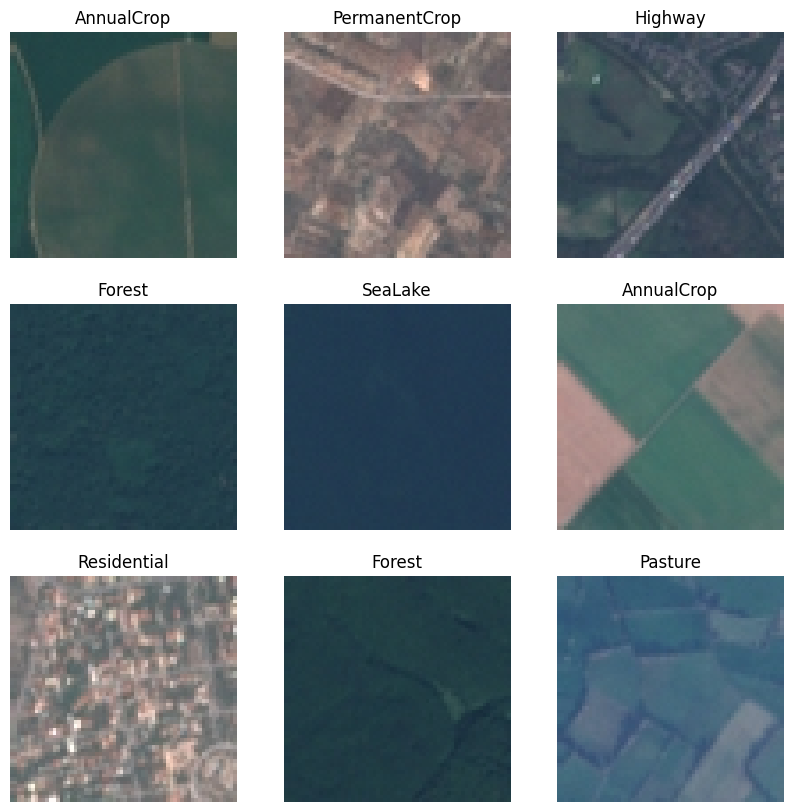

In [ ]:
class_names = train_ds.class_names
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
img_size = 128
resize_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(img_size, img_size),
])

train_ds = train_ds.map(lambda x,y:(resize_rescale (x), y))
val_ds = val_ds.map(lambda x,y:(resize_rescale (x), y))

train_ds = train_ds.map(lambda x, y : (tf.keras.applications.mobilenet_v2.preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y : (tf.keras.applications.mobilenet_v2.preprocess_input(x), y))

base_model = tf.keras.applications.MobileNetV2(
    input_shape = (img_size, img_size, 3),
    include_top = False,
    weights = 'imagenet'
)
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation = 'softmax')
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history = model.fit(train_ds, validation_data= val_ds, epochs = 10)

Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 50s 46ms/step - accuracy: 0.8812 - loss: 0.3517 - val_accuracy: 0.9239 - val_loss: 0.2220
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.9267 - loss: 0.2082 - val_accuracy: 0.9217 - val_loss: 0.2326
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9409 - loss: 0.1703 - val_accuracy: 0.9281 - val_loss: 0.2119
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.9492 - loss: 0.1458 - val_accuracy: 0.9294 - val_loss: 0.2190
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.9545 - loss: 0.1269 - val_accuracy: 0.9285 - val_loss: 0.2203
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9600 - loss: 0.1145 - val_accuracy: 0.9333 - val_loss: 0.2078
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.9650 - loss: 0.1000 - val_accuracy: 0.9317 - val_loss: 0.2299
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.9674 - loss: 0.0906 - 

In [ ]:
model.evaluate(val_ds)

169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9302 - loss: 0.2630


[0.26298534870147705, 0.9301851987838745]

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable  = False

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-5),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

fine_tune_epoch = 10
history_fine = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = fine_tune_epoch
)

Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 43s 39ms/step - accuracy: 0.8501 - loss: 0.7259 - val_accuracy: 0.9169 - val_loss: 0.5009
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9053 - loss: 0.3762 - val_accuracy: 0.9263 - val_loss: 0.3633
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.9230 - loss: 0.2722 - val_accuracy: 0.9289 - val_loss: 0.3093
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.9365 - loss: 0.1991 - val_accuracy: 0.9315 - val_loss: 0.2756
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9450 - loss: 0.1672 - val_accuracy: 0.9328 - val_loss: 0.2574
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.9527 - loss: 0.1456 - val_accuracy: 0.9346 - val_loss: 0.2511
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.9611 - loss: 0.1170 - val_accuracy: 0.9341 - val_loss: 0.2467
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.9661 - loss: 0.0978 - 

In [ ]:
zip_path = "/content/drive/MyDrive/Dera_Baba_Nanak.zip"
extract_path = "/content/DBN_extracted"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

import os
for root, dirs, files in os.walk(extract_path):
    for f in files:
        print(os.path.join(root, f))

/content/DBN_extracted/2025-10-25-00_00_2025-11-15-23_59_Sentinel-2_L2A_B04_(Raw).tiff
/content/DBN_extracted/2025-10-25-00_00_2025-11-15-23_59_Sentinel-2_L2A_B08_(Raw).tiff
/content/DBN_extracted/2025-10-25-00_00_2025-11-15-23_59_Sentinel-2_L2A_B03_(Raw).tiff
/content/DBN_extracted/2025-10-25-00_00_2025-11-15-23_59_Sentinel-2_L2A_B02_(Raw).tiff


In [ ]:
import rasterio
import numpy as np

with rasterio.open('/content/DBN_extracted/2025-10-25-00_00_2025-11-15-23_59_Sentinel-2_L2A_B04_(Raw).tiff') as src:
    red = src.read(1)
    profile = src.profile
with rasterio.open('/content/DBN_extracted/2025-10-25-00_00_2025-11-15-23_59_Sentinel-2_L2A_B03_(Raw).tiff') as src:
    green = src.read(1)
with rasterio.open('/content/DBN_extracted/2025-10-25-00_00_2025-11-15-23_59_Sentinel-2_L2A_B02_(Raw).tiff') as src:
    blue = src.read(1)

image = np.dstack([red, green, blue])

# Scale from raw Sentinel-2 reflectance values to 0-255
clip_value = np.percentile(image, 98)
print("Clip value used:", clip_value)
image_scaled = np.clip(image, 0, clip_value)
image_scaled = (image_scaled / clip_value * 255).astype('uint8')
print("Scaled image shape:", image_scaled.shape)
print("Min/Max values:", image_scaled.min(), image_scaled.max())

Clip value used: 10715.0
Scaled image shape: (1789, 2500, 3)
Min/Max values: 0 255


In [ ]:
print("Red band shape:", red.shape)
print("Green band shape:", green.shape)
print("Blue band shape:", blue.shape)

Red band shape: (1789, 2500)
Green band shape: (1789, 2500)
Blue band shape: (1789, 2500)


In [ ]:
tile_size = 128
tiles = []
positions = []

for row in range(0, image.shape[0] - tile_size, tile_size):
  for col in range (0,image.shape[1] - tile_size, tile_size):
    tile = image_scaled[row:row+tile_size, col:col+tile_size]
    tiles.append(tile)
    positions.append((row,col))

tiles = np.array(tiles)

In [ ]:
tiles_preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(tiles.astype('float32'))

predictions = model.predict(tiles_preprocessed)
predicted_classes = np.argmax(predictions, axis = 1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step


AnnualCrop: 28 tiles
Industrial: 4 tiles
Pasture: 41 tiles
PermanentCrop: 164 tiles
Residential: 5 tiles
River: 5 tiles


(np.float64(-0.5), np.float64(2499.5), np.float64(1788.5), np.float64(-0.5))

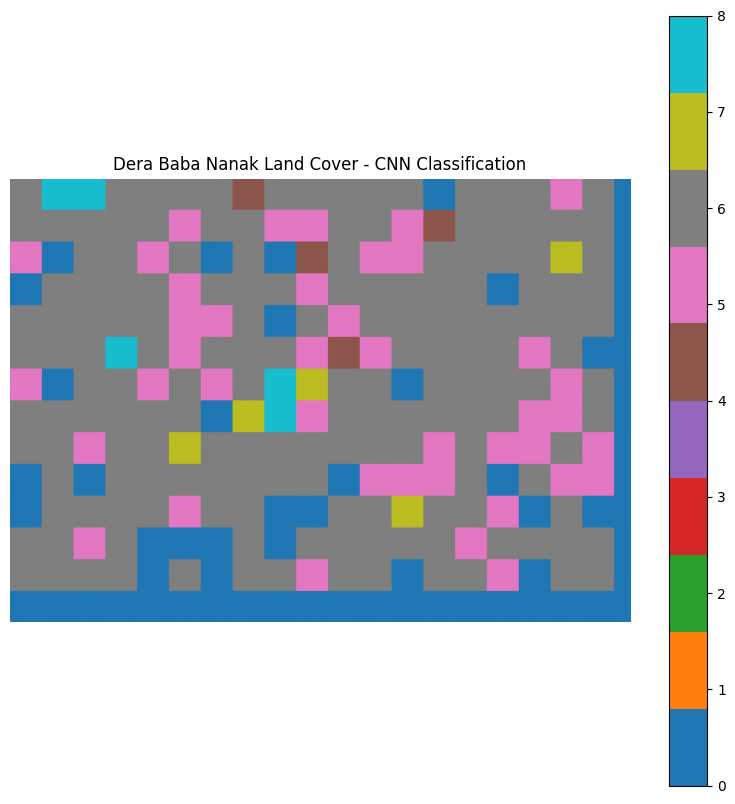

In [ ]:
classified_map = np.zeros((image.shape[0], image.shape[1]), dtype = int)

for (row, col), pred_class in zip(positions, predicted_classes):
  classified_map[row:row+tile_size, col:col+tile_size] = pred_class


unique, counts = np.unique(predicted_classes, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"{class_names[cls]}: {count} tiles")


plt.figure(figsize=(10,10))
plt.imshow(classified_map, cmap='tab10')
plt.title('Dera Baba Nanak Land Cover - CNN Classification')
plt.colorbar(ticks=range(10))
plt.axis('off')


In [ ]:
# Load the infrared band
with rasterio.open('/content/DBN_extracted/2025-10-25-00_00_2025-11-15-23_59_Sentinel-2_L2A_B08_(Raw).tiff') as src:
    nir = src.read(1)

river_class_index = class_names.index('River')
river_tile_positions = [pos for pos, pred in zip(positions, predicted_classes) if pred == river_class_index]
print(f"Tiles classified as River: {len(river_tile_positions)}")

confirmed_water = 0
for (row, col) in river_tile_positions:
    green_tile = green[row:row+tile_size, col:col+tile_size].astype('float32')
    nir_tile = nir[row:row+tile_size, col:col+tile_size].astype('float32')
    ndwi_tile = (green_tile - nir_tile) / (green_tile + nir_tile + 1e-6)
    mean_ndwi = ndwi_tile.mean()
    is_water = mean_ndwi > 0
    confirmed_water += is_water
    print(f"Tile ({row},{col}): mean NDWI = {mean_ndwi:.3f} -> {'WATER confirmed' if is_water else 'false positive'}")

print(f"\n{confirmed_water}/{len(river_tile_positions)} 'River' tiles confirmed as genuine water")

Tiles classified as River: 5
Tile (0,128): mean NDWI = -0.107 -> false positive
Tile (0,256): mean NDWI = -0.195 -> false positive
Tile (640,384): mean NDWI = -0.288 -> false positive
Tile (768,1024): mean NDWI = -0.366 -> false positive
Tile (896,1024): mean NDWI = -0.362 -> false positive

0/5 'River' tiles confirmed as genuine water
